#Diabet kasalligiga tashxis qoʻyish

#Ustunlar

- Pregnancies: homilador bo'lish soni
- Glucose: glyukozaga test natijasi
- BloodPressure: diastolik qon bosimi (mm Hg)
- SkinThickness: Triceps teri burmasining qalinligi (mm)
- Insulin: 2 soatlik sarum insulini (mu U/ml)
- BMI: Tana massasi indeksi (vazn kg / (m bo'yi) ^ 2)
- DiabetesPedigreeFunction: diabetning naslchilik funktsiyasi
- Age: Yosh (yil)
- Outcome: Class (0 - diabet yo'q, 1 - diabet)

Dataset: https://github.com/anvarnarz/praktikum_datasets/blob/main/diabetes.csv



#Diabetes Diagnosis Classification
#Dataset columns:

- Pregnancies — Number of times pregnant
- Glucose — Plasma glucose concentration (2-hour oral glucose tolerance test)
- BloodPressure — Diastolic blood pressure (mm Hg)
- SkinThickness — Triceps skin fold thickness (mm)
- Insulin — 2-hour serum insulin (mu U/ml)
- BMI — Body mass index (weight in kg / height in m²)
- DiabetesPedigreeFunction — Diabetes pedigree function (hereditary likelihood)
- Age — Age in years
- Outcome — Target class (0 = no diabetes, 1 = diabetes)

Dataset: https://github.com/anvarnarz/praktikum_datasets/blob/main/diabetes.csv


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/diabetes.csv')
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
308,0,128,68,19,180,30.5,1.391,25,1
1,1,85,66,29,0,26.6,0.351,31,0
232,1,79,80,25,37,25.4,0.583,22,0
578,10,133,68,0,0,27.0,0.245,36,0
125,1,88,30,42,99,55.0,0.496,26,1
274,13,106,70,0,0,34.2,0.251,52,0
191,9,123,70,44,94,33.1,0.374,40,0
541,3,128,72,25,190,32.4,0.549,27,1
99,1,122,90,51,220,49.7,0.325,31,1
438,1,97,70,15,0,18.2,0.147,21,0


#Introduction to df

In [108]:
df.shape

(768, 9)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [110]:
df[['Glucose', 'BMI', 'BloodPressure', 'Insulin', 'SkinThickness']].eq(0).sum()

,0
Glucose,5
BMI,11
BloodPressure,35
Insulin,374
SkinThickness,227


In [111]:
# change columns to float
cols = ['Glucose', 'BMI', 'BloodPressure', 'Insulin', 'SkinThickness']
df[cols] = df[cols].astype(float)

for col in cols:
    for outcome in [0, 1]:
        mask = (df[col] == 0) & (df['Outcome'] == outcome)
        median_val = df[(df[col] != 0) & (df['Outcome'] == outcome)][col].median()
        df.loc[mask, col] = median_val

In [112]:
corr_matrix = df.corr().abs()
corr_matrix.style.background_gradient(cmap = 'coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130155,0.209151,0.089028,0.058767,0.023890,0.033523,0.544341,0.221898
Glucose,0.130155,1.000000,0.225141,0.229289,0.490015,0.236171,0.138353,0.268910,0.495990
BloodPressure,0.209151,0.225141,1.000000,0.199349,0.070128,0.286399,0.001443,0.325135,0.174469
SkinThickness,0.089028,0.229289,0.199349,1.000000,0.200129,0.566086,0.106280,0.129537,0.295138
Insulin,0.058767,0.490015,0.070128,0.200129,1.000000,0.238443,0.146878,0.123629,0.377081
BMI,0.023890,0.236171,0.286399,0.566086,0.238443,1.000000,0.152771,0.027849,0.315577
DiabetesPedigreeFunction,0.033523,0.138353,0.001443,0.106280,0.146878,0.152771,1.000000,0.033561,0.173844
Age,0.544341,0.268910,0.325135,0.129537,0.123629,0.027849,0.033561,1.000000,0.238356
Outcome,0.221898,0.495990,0.174469,0.295138,0.377081,0.315577,0.173844,0.238356,1.000000


In [113]:
df.Outcome.value_counts()

,count
Outcome,
0,500
1,268


In [114]:
df.corrwith(df['Outcome']).sort_values(ascending = False)

,0
Outcome,1.000000
Glucose,0.495990
Insulin,0.377081
BMI,0.315577
SkinThickness,0.295138
Age,0.238356
Pregnancies,0.221898
BloodPressure,0.174469
DiabetesPedigreeFunction,0.173844


#Train Test Split

In [115]:
X = df.drop('Outcome', axis = 1)
y = df['Outcome']

In [116]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size=0.2, random_state = 42)

#Standard Scaler

In [117]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
x_train_scaled = standard_scaler.fit_transform(x_train)
x_test_scaled = standard_scaler.transform(x_test)

#Find the best K value

In [118]:
# GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors':np.arange(1,31)}
knn_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv = 5)
knn_gscv.fit(x_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])})

In [119]:
knn_gscv.cv_results_['rank_test_score']

array([30, 29, 23, 28, 24, 27, 14, 21, 15, 25, 19, 20, 18, 16, 12, 12,  3,
        7,  8,  8,  2,  8,  4,  4,  1, 11,  6, 17, 21, 26], dtype=int32)

In [120]:
knn_gscv.best_params_

{'n_neighbors': np.int64(25)}

**The best k value is 25**

In [121]:
knn_gscv.best_score_

np.float64(0.8257230441156871)

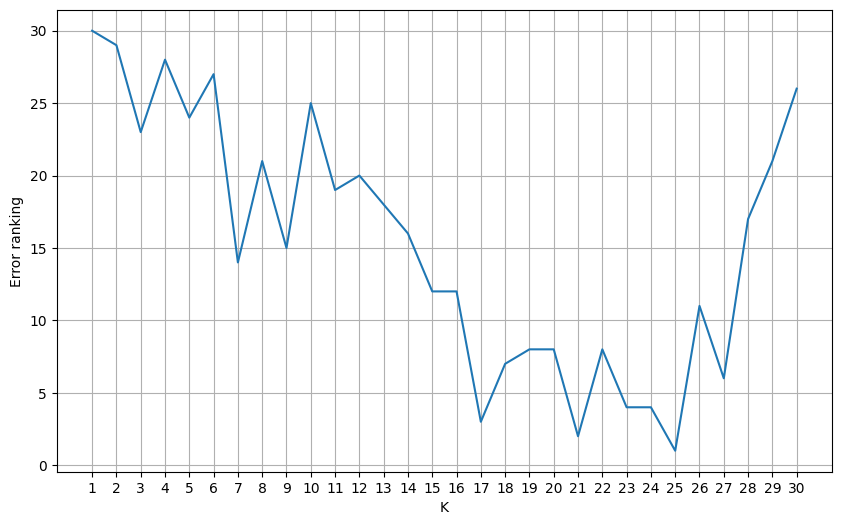

In [122]:
plt.figure(figsize = (10,6))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(param_grid['n_neighbors'])
plt.xlabel('K')
plt.ylabel('Error ranking')
plt.grid()
plt.show()

#Machine Learning

In [123]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 25)

knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=25)

#Testing

In [124]:
y_predict = knn.predict(x_test_scaled)

In [125]:
df_test = pd.DataFrame({'Real':y_test.values, 'Predict':y_predict}, index = y_test.index)
df_test.sample(10)

,Real,Predict
24,1,1
345,0,0
421,0,0
543,0,0
560,1,1
698,0,0
112,0,0
678,1,0
140,0,0
402,1,0


#Model Evaluation

Confusion matrix


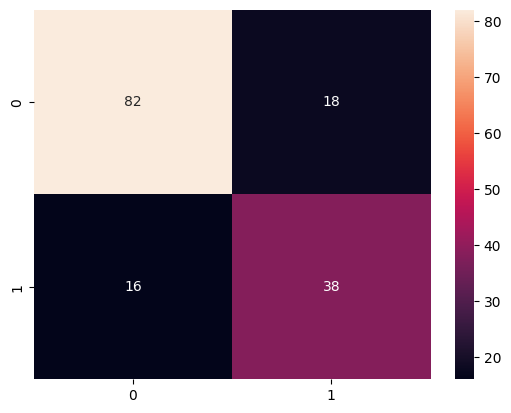

In [126]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_predict), annot = True)
plt.show()

Jaccard score

In [127]:
from sklearn.metrics import jaccard_score
print(jaccard_score(y_test, y_predict))

0.5277777777777778


Classification report

In [128]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))


              precision    recall  f1-score   support

           0       0.84      0.82      0.83       100
           1       0.68      0.70      0.69        54

    accuracy                           0.78       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.78      0.78       154



#Cross Val Predict

In [129]:
from sklearn.model_selection import cross_val_predict
predict = cross_val_predict(estimator = knn, X = X, y = y, cv = 5)

#Model Evaluation
from sklearn.metrics import classification_report
print("Classification report:\n", classification_report(y,predict))

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89       500
           1       0.79      0.79      0.79       268

    accuracy                           0.85       768
   macro avg       0.84      0.84      0.84       768
weighted avg       0.85      0.85      0.85       768

